# Used Car Price Prediction

This notebook explores a public used-car dataset and trains regression models to estimate a car's listed selling price from its age, mileage, brand, fuel, transmission, seller type, and owner history.

**Dataset:** [Vehicle dataset from cardekho — Kaggle](https://www.kaggle.com/datasets/nehalbirla/vehicle-dataset-from-cardekho). This analysis uses `CAR DETAILS FROM CAR DEKHO.csv` from the downloaded archive (4,340 rows, eight columns in the source file). The archive also contains other overlapping datasets; they are not combined here.

**Important limitations:** the source has no documented train/test collection protocol or currency/unit metadata in this CSV. Prices are modeled in the units supplied by the file and results apply to this dataset's listings, not guaranteed market values. Duplicate listings are removed. A fixed age reference year (2021) is used for reproducible features; it is one year after the latest model year in this file. The model is for learning and demonstration, not a valuation service.

## 1. Imports and data location

The data-folder lookup works when the notebook is run from this project directory or its parent `DATA SCIENCE` directory.

In [1]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["figure.dpi"] = 110

data_candidates = [
    Path.cwd() / "data",
    Path.cwd().parent / "data",
    Path.cwd() / "Car Price Prediction" / "data",
]
data_dir = next((path for path in data_candidates if path.is_dir()), None)
if data_dir is None:
    raise FileNotFoundError("Could not find the project's data/ folder. Run from Car Price Prediction/ or DATA SCIENCE/.")
data_path = data_dir / "CAR DETAILS FROM CAR DEKHO.csv"
if not data_path.is_file():
    raise FileNotFoundError(f"Expected Kaggle CSV was not found: {data_path}")
print(f"Dataset: {data_path.resolve()}")

Dataset: C:\Users\Sreeyakeshrajan_T\OneDrive\Desktop\OIBSIP\DATA SCIENCE\Car Price Prediction\data\CAR DETAILS FROM CAR DEKHO.csv


## 2. Load and inspect the source

Inspect dimensions, field names, types, null counts, and sample records before cleaning.

In [2]:
raw = pd.read_csv(data_path)
print(f"Shape: {raw.shape[0]:,} rows x {raw.shape[1]} columns")
print("Columns:", raw.columns.tolist())
display(raw.head())
print("\nData types:")
display(raw.dtypes.rename("dtype").to_frame())
print("\nNulls by column:")
display(raw.isna().sum().rename("missing_count").to_frame())
print(f"\nExact duplicate rows: {raw.duplicated().sum():,}")

Shape: 4,340 rows x 8 columns
Columns: ['name', 'year', 'selling_price', 'km_driven', 'fuel', 'seller_type', 'transmission', 'owner']


,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
0,Maruti 800 AC,2007,60000,70000,Petrol,Individual,Manual,First Owner
1,Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Individual,Manual,First Owner
2,Hyundai Verna 1.6 SX,2012,600000,100000,Diesel,Individual,Manual,First Owner
3,Datsun RediGO T Option,2017,250000,46000,Petrol,Individual,Manual,First Owner
4,Honda Amaze VX i-DTEC,2014,450000,141000,Diesel,Individual,Manual,Second Owner



Data types:


,dtype
name,str
year,int64
selling_price,int64
km_driven,int64
fuel,str
seller_type,str
transmission,str
owner,str



Nulls by column:


,missing_count
name,0
year,0
selling_price,0
km_driven,0
fuel,0
seller_type,0
transmission,0
owner,0



Exact duplicate rows: 763


## 3. Clean and engineer features

Normalize column and text whitespace; standardize categorical letter case; convert numeric fields safely; remove exact duplicate listings; and discard records with invalid target prices or model years. Brand is extracted as the first token of the listing name. Car age uses the documented constant `AGE_REFERENCE_YEAR` so rerunning the notebook produces the same features.

In [3]:
df = raw.copy()
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_", regex=False)
required_columns = {"name", "year", "selling_price", "km_driven", "fuel", "seller_type", "transmission", "owner"}
missing_columns = required_columns - set(df.columns)
if missing_columns:
    raise ValueError(f"The selected source file is missing required columns: {sorted(missing_columns)}")

text_columns = ["name", "fuel", "seller_type", "transmission", "owner"]
for column in text_columns:
    df[column] = df[column].astype("string").str.strip()
    df[column] = df[column].replace("", pd.NA)
    df[column] = df[column].str.casefold().str.title()

for column in ["year", "selling_price", "km_driven"]:
    df[column] = pd.to_numeric(df[column], errors="coerce")

duplicates_before = int(df.duplicated().sum())
invalid_prices = int((df["selling_price"].le(0) | df["selling_price"].isna()).sum())
invalid_years = int(df["year"].isna().sum())
df = df.drop_duplicates().copy()
df = df.dropna(subset=list(required_columns)).copy()
df = df.loc[(df["selling_price"] > 0) & (df["year"] > 0) & (df["km_driven"] >= 0)].copy()

AGE_REFERENCE_YEAR = 2021  # Fixed reference: latest source model year (2020) + 1.
df["car_age"] = AGE_REFERENCE_YEAR - df["year"]
df["brand"] = df["name"].str.split().str[0].str.title()

print(f"Exact duplicate rows removed: {duplicates_before:,}")
print(f"Rows with invalid/missing price before cleaning: {invalid_prices:,}")
print(f"Rows with missing/unparseable year before cleaning: {invalid_years:,}")
print(f"Rows retained: {len(df):,} / {len(raw):,}")
print(f"Model years: {int(df['year'].min())}–{int(df['year'].max())}; age reference year: {AGE_REFERENCE_YEAR}")
print(f"Distinct brands: {df['brand'].nunique()}")
print("Remaining nulls:")
display(df[list(required_columns) + ["car_age", "brand"]].isna().sum().rename("missing_count").to_frame())
print("Normalized category values:")
for column in ["fuel", "transmission", "seller_type", "owner"]:
    print(f"{column}: {sorted(df[column].dropna().unique().tolist())}")

Exact duplicate rows removed: 763
Rows with invalid/missing price before cleaning: 0
Rows with missing/unparseable year before cleaning: 0
Rows retained: 3,577 / 4,340
Model years: 1992–2020; age reference year: 2021
Distinct brands: 29
Remaining nulls:


,missing_count
fuel,0
selling_price,0
km_driven,0
transmission,0
owner,0
name,0
seller_type,0
year,0
car_age,0
brand,0


Normalized category values:
fuel: ['Cng', 'Diesel', 'Electric', 'Lpg', 'Petrol']
transmission: ['Automatic', 'Manual']
seller_type: ['Dealer', 'Individual', 'Trustmark Dealer']
owner: ['First Owner', 'Fourth & Above Owner', 'Second Owner', 'Test Drive Car', 'Third Owner']


## 4. Explore selling prices

Used-car prices are often skewed, so inspect both the original price scale and a logarithmic view. These charts describe the cleaned listings before model fitting.

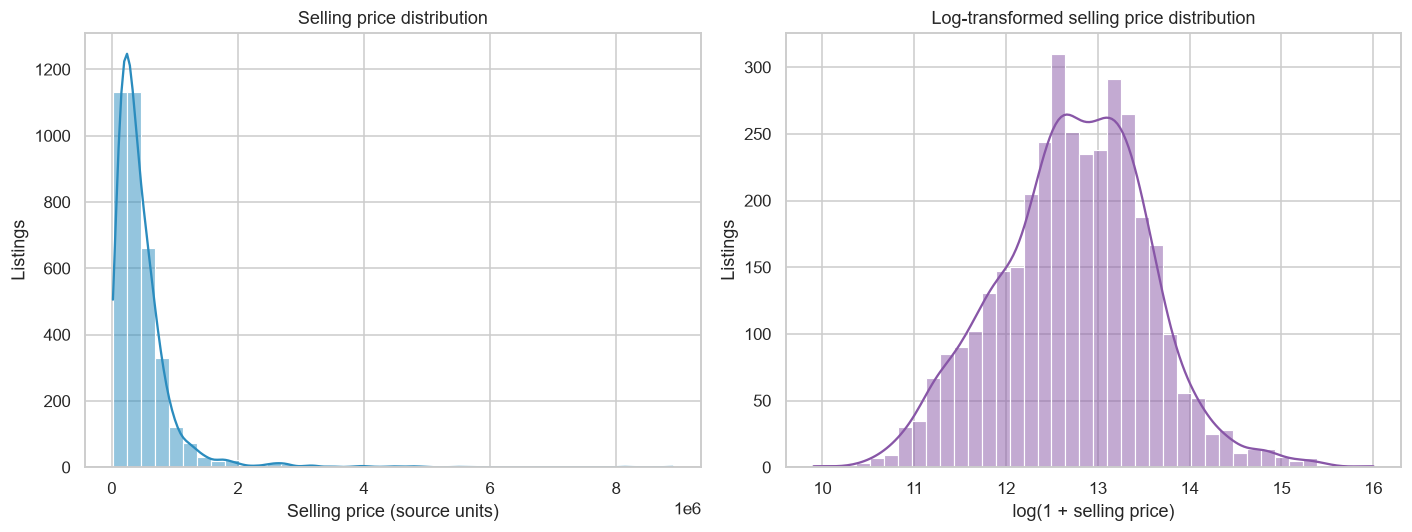

,selling_price
count,3577.00
mean,473912.54
std,509301.81
min,20000.00
25%,200000.00
50%,350000.00
75%,600000.00
max,8900000.00


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.histplot(df["selling_price"], bins=40, kde=True, ax=axes[0], color="#2b8cbe")
axes[0].set(title="Selling price distribution", xlabel="Selling price (source units)", ylabel="Listings")
sns.histplot(np.log1p(df["selling_price"]), bins=40, kde=True, ax=axes[1], color="#8856a7")
axes[1].set(title="Log-transformed selling price distribution", xlabel="log(1 + selling price)", ylabel="Listings")
plt.tight_layout()
plt.show()
display(df["selling_price"].describe().rename("selling_price").to_frame().round(2))

**Observation prompt:** compare the tail and concentration in the two panels. The log panel is for visualizing the distribution only; model metrics below remain in the original price units.

## 5. Selling price by fuel type

Show fuel groups with a reasonable number of observations to make the box plot legible; include sample counts so small groups are not mistaken for broad market patterns.

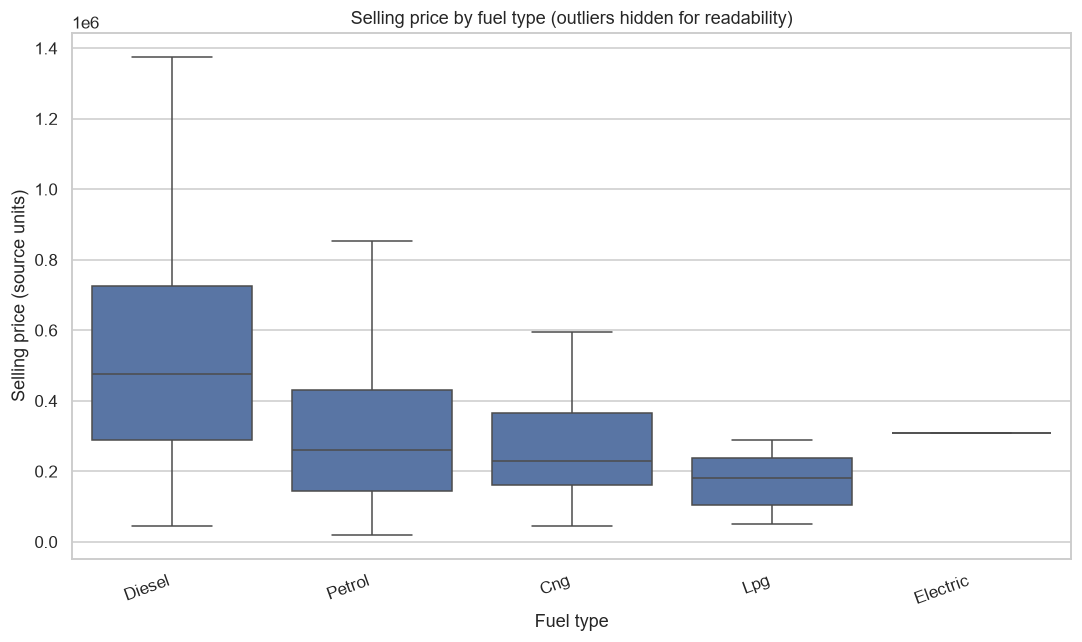

,listing_count
fuel,
Diesel,1800
Petrol,1717
Cng,37
Lpg,22
Electric,1


In [5]:
fuel_counts = df["fuel"].value_counts()
fuel_order = fuel_counts.index.tolist()
plt.figure(figsize=(10, 6))
ax = sns.boxplot(data=df, x="fuel", y="selling_price", order=fuel_order, showfliers=False)
ax.set(title="Selling price by fuel type (outliers hidden for readability)", xlabel="Fuel type", ylabel="Selling price (source units)")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()
display(fuel_counts.rename("listing_count").to_frame())

**Observation prompt:** compare medians and interquartile ranges, while referring to the sample-count table. The boxes do not adjust for car age, brand, mileage, or other factors.

## 6. Price versus car age

The scatter plot uses a sample if there are more than 2,000 cleaned rows, keeping the notebook responsive. The sample is drawn with a fixed random seed and does not affect model training.

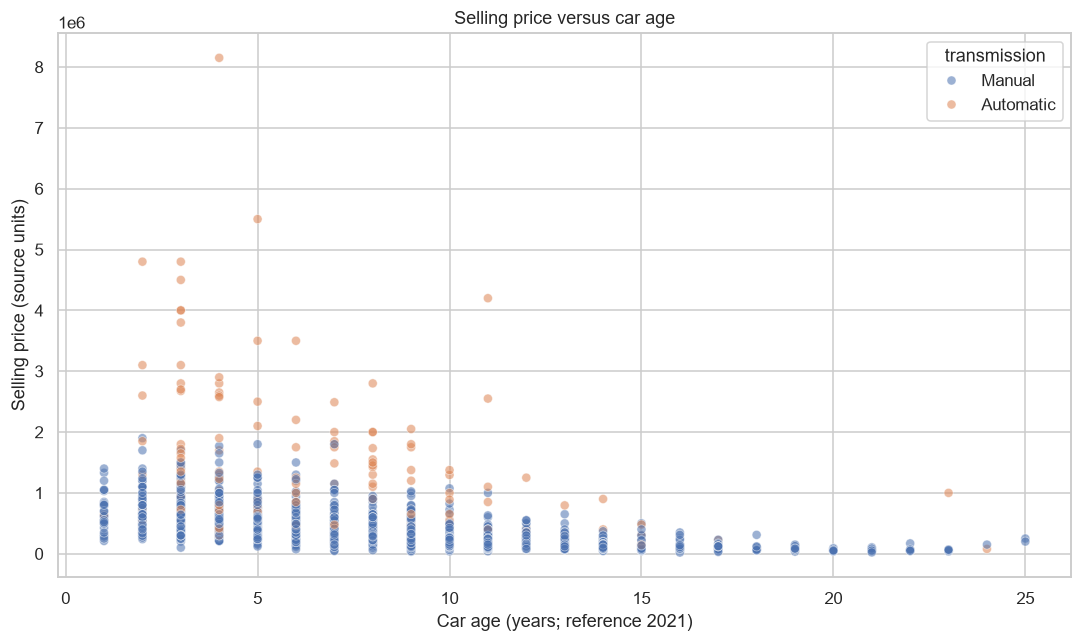

In [6]:
plot_df = df.sample(n=2000, random_state=42) if len(df) > 2000 else df
plt.figure(figsize=(10, 6))
ax = sns.scatterplot(data=plot_df, x="car_age", y="selling_price", hue="transmission", alpha=0.55, s=35)
ax.set(title="Selling price versus car age", xlabel=f"Car age (years; reference {AGE_REFERENCE_YEAR})", ylabel="Selling price (source units)")
plt.tight_layout()
plt.show()

**Observation prompt:** look for broad patterns and spread at similar ages. Individual prices vary widely, and this bivariate chart does not isolate the effect of age.

## 7. Numerical feature correlation

This heatmap includes the engineered car age, distance driven, year, and target price. It is an exploratory association view, not a causal analysis. Correlations do not capture categorical factors or nonlinear relationships.

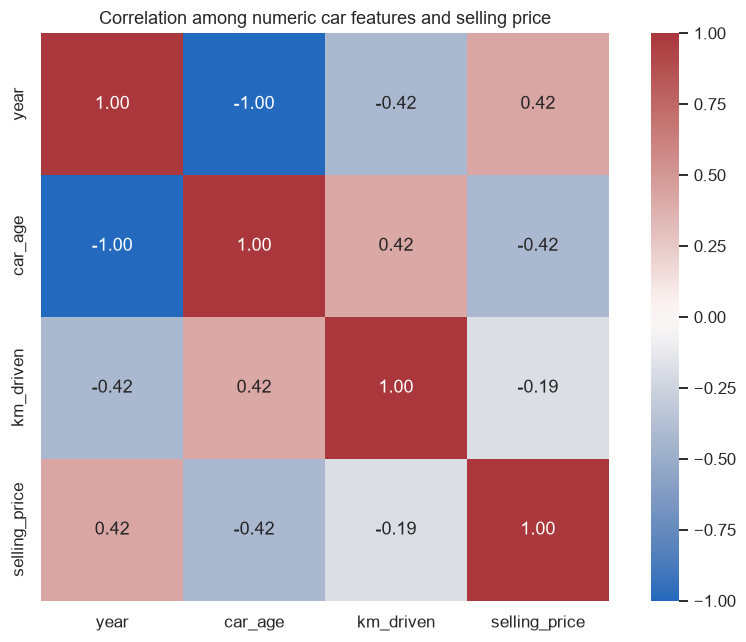

,year,car_age,km_driven,selling_price
year,1.000,-1.000,-0.417,0.424
car_age,-1.000,1.000,0.417,-0.424
km_driven,-0.417,0.417,1.000,-0.187
selling_price,0.424,-0.424,-0.187,1.000


In [7]:
numeric_for_corr = df[["year", "car_age", "km_driven", "selling_price"]].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(numeric_for_corr, annot=True, fmt=".2f", cmap="vlag", center=0, vmin=-1, vmax=1, square=True)
plt.title("Correlation among numeric car features and selling price")
plt.tight_layout()
plt.show()
display(numeric_for_corr.round(3))

## 8. Prepare features and train/test split

The target is `selling_price`. Predictors include derived `car_age` and `brand` plus mileage and categorical fuel, seller, transmission, and owner information. The raw `year` is excluded because it duplicates the information in age. The full listing name is not used because it can create a high-cardinality, memorization-prone feature. Numeric missing values are median-imputed and categorical values are most-frequent-imputed inside each training pipeline. One-hot encoding is fit only on the training split.

In [8]:
target = "selling_price"
numeric_features = ["car_age", "km_driven"]
categorical_features = ["brand", "fuel", "seller_type", "transmission", "owner"]
feature_columns = numeric_features + categorical_features
X = df[feature_columns].copy()
y = df[target].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)
print(f"Training rows: {len(X_train):,} | Test rows: {len(X_test):,}")
print(f"Training feature count before encoding: {X_train.shape[1]}")
print("Predictor columns:", feature_columns)

Training rows: 2,861 | Test rows: 716
Training feature count before encoding: 7
Predictor columns: ['car_age', 'km_driven', 'brand', 'fuel', 'seller_type', 'transmission', 'owner']


## 9. Preprocessing and regression models

Compare Linear Regression with a Random Forest Regressor. Both use the same training-only imputing/encoding steps. The numeric scaling helps the linear model; tree-based regression does not require scaled inputs, but sharing preprocessing keeps comparison straightforward.

In [9]:
numeric_preprocessor = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])
categorical_preprocessor = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])
preprocessor = ColumnTransformer([
    ("numeric", numeric_preprocessor, numeric_features),
    ("categorical", categorical_preprocessor, categorical_features),
])

models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(
        n_estimators=300, min_samples_leaf=2, random_state=42, n_jobs=-1
    ),
}
fitted_models = {}
predictions = {}
metric_rows = []

for model_name, estimator in models.items():
    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", estimator),
    ])
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    fitted_models[model_name] = pipeline
    predictions[model_name] = y_pred
    metric_rows.append({
        "Model": model_name,
        "MAE": mean_absolute_error(y_test, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, y_pred)),
        "R2": r2_score(y_test, y_pred),
    })

results = pd.DataFrame(metric_rows).set_index("Model").sort_values("RMSE")
display(results.round(3))

,MAE,RMSE,R2
Model,,,
Random Forest,156155.553,355902.592,0.607
Linear Regression,179642.129,384722.830,0.541


## 10. Evaluate and compare models

**MAE** and **RMSE** are in the source selling-price units; lower is better. RMSE penalizes larger errors more heavily. **R²** summarizes test-set variance explained relative to predicting the test mean; it can be negative. The best model below is selected by the lowest held-out RMSE, not by training fit.

Best model by test RMSE: Random Forest


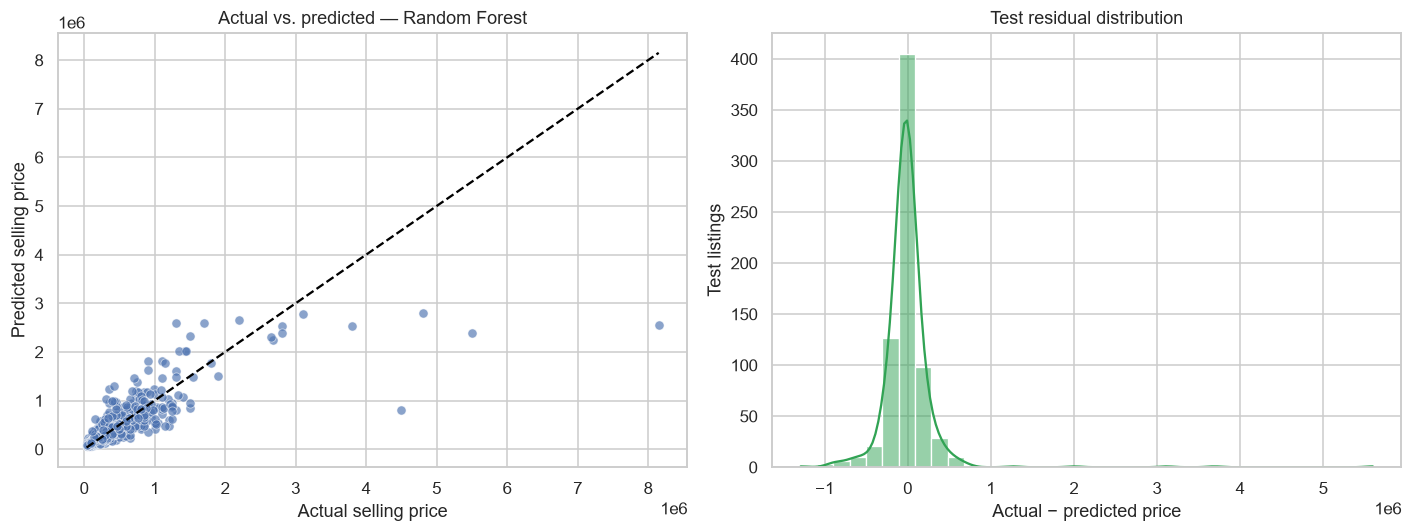

In [10]:
best_model_name = results.index[0]
best_model = fitted_models[best_model_name]
print(f"Best model by test RMSE: {best_model_name}")
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.scatterplot(x=y_test, y=predictions[best_model_name], alpha=0.65, ax=axes[0])
limits = [min(y_test.min(), predictions[best_model_name].min()), max(y_test.max(), predictions[best_model_name].max())]
axes[0].plot(limits, limits, linestyle="--", color="black")
axes[0].set(title=f"Actual vs. predicted — {best_model_name}", xlabel="Actual selling price", ylabel="Predicted selling price")

residuals = y_test.to_numpy() - predictions[best_model_name]
sns.histplot(residuals, bins=35, kde=True, ax=axes[1], color="#31a354")
axes[1].set(title="Test residual distribution", xlabel="Actual − predicted price", ylabel="Test listings")
plt.tight_layout()
plt.show()

**Observation prompt:** points near the diagonal correspond to more accurate predictions; residuals centered near zero indicate less directional bias overall. Check the metric table alongside the plots, and remember this is one random holdout split.

## 11. Feature importance for the selected model

For a Random Forest winner, display impurity-based feature importance. If Linear Regression wins, display absolute standardized coefficient magnitude. Both measures are model-specific and should not be interpreted as causal effects.

,Random Forest impurity importance
numeric__car_age,0.2268
categorical__transmission_Automatic,0.1465
categorical__transmission_Manual,0.1304
numeric__km_driven,0.1260
categorical__fuel_Diesel,0.0822
categorical__brand_Audi,0.0500
categorical__fuel_Petrol,0.0446
categorical__brand_Toyota,0.0378
categorical__brand_Land,0.0250
categorical__brand_Bmw,0.0146


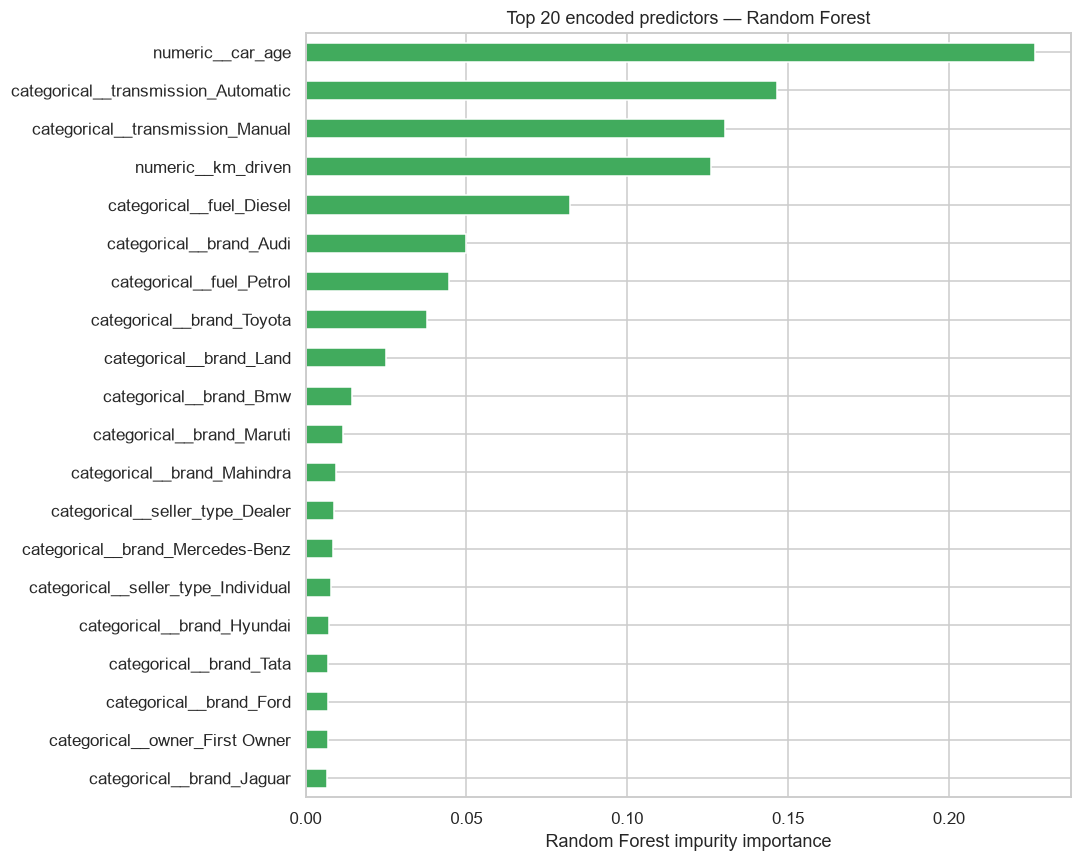

In [11]:
fitted_preprocessor = best_model.named_steps["preprocessor"]
fitted_estimator = best_model.named_steps["model"]
encoded_feature_names = fitted_preprocessor.get_feature_names_out()

if hasattr(fitted_estimator, "feature_importances_"):
    importance_values = fitted_estimator.feature_importances_
    importance_label = "Random Forest impurity importance"
elif hasattr(fitted_estimator, "coef_"):
    importance_values = np.abs(np.ravel(fitted_estimator.coef_))
    importance_label = "Absolute Linear Regression coefficient magnitude"
else:
    raise TypeError(f"No supported feature-importance measure for {best_model_name}")

importance = pd.Series(importance_values, index=encoded_feature_names).sort_values(ascending=False).head(20)
display(importance.rename(importance_label).to_frame().round(4))
ax = importance.sort_values().plot(kind="barh", figsize=(10, 8), color="#41ab5d")
ax.set(title=f"Top 20 encoded predictors — {best_model_name}", xlabel=importance_label, ylabel="")
plt.tight_layout()
plt.show()

## 12. Data-driven summary

The following summary is generated from the actual cleaned dataset and test predictions whenever the notebook runs. Use it together with the limitation notes above.

In [12]:
best_metrics = results.loc[best_model_name]
print(f"After exact-deduplication and required-field validation, {len(df):,} listings were retained.")
print(f"The cleaned data span model years {int(df['year'].min())}–{int(df['year'].max())} and {df['brand'].nunique()} extracted brands.")
print(f"On the 20% holdout split, {best_model_name} ranked first by RMSE.")
print(f"Test MAE: {best_metrics['MAE']:,.2f}; RMSE: {best_metrics['RMSE']:,.2f}; R²: {best_metrics['R2']:.3f}.")
print("These scores describe this split and this Kaggle sample only; validate on newer, independently collected listings before practical use.")

After exact-deduplication and required-field validation, 3,577 listings were retained.
The cleaned data span model years 1992–2020 and 29 extracted brands.
On the 20% holdout split, Random Forest ranked first by RMSE.
Test MAE: 156,155.55; RMSE: 355,902.59; R²: 0.607.
These scores describe this split and this Kaggle sample only; validate on newer, independently collected listings before practical use.
